In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv2.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 5
N_TICKS = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]

In [4]:
# метрика лосса: mae где нормировка по корню дисперсии: самое научное, что я придумал/нашел
# + байесовское обучение оптуной, все диапазоны я выбрал интуитивно руководствуясь логикой/статьями, а также по результатам прошлых запусков
def loss_mse(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret"]
    arrs = ["autocorrelation_on_ret", "autocorrelation_on_abs_ret"]
    error = 0
    for i in arrs:
        m_params[i] = m_params[i].mean()
    for i in num + arrs:
        error += ((t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]) / t_params.loc[t_params["param"] == i, "std"].iloc[0]) ** 2
    return error / len(num + arrs)

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 20, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 3, 50),
        'Chartist': trial.suggest_int('Chartist', 30, 120),
        'Universalist': trial.suggest_int('Universalist', 5, 50),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 0.05, 100, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 0.005, 10, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -5, 0),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 100, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 100, log=True),
        'Exchange_Volume': trial.suggest_int('Exchange_Volume', 1000, 20000)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(volume=params['Exchange_Volume'], std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'], divs_drifted=True)
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, params['Exchange_Volume']) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, params['Exchange_Volume']) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, params['Exchange_Volume']) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, params['Exchange_Volume']) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, params['Exchange_Volume']) for _ in range(0)],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_mse(target_params, model_params))
        except Exception:
            continue

    if len(errors) != N_RUNS:
        return 1000
    return float(np.mean(errors))

In [5]:
# само обучение
study = optuna.create_study(study_name="calibration_mse_v3 (mm-;volume+;diff diap)", direction="minimize", storage="sqlite:///calibration_mse_3.db",  load_if_exists=True)
study.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study.best_params
best_score = study.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-03-30 11:46:27,462] A new study created in RDB with name: calibration_mse_v3 (mm-;volume+;diff diap)
Best trial: 0. Best value: 171.433:   0%|          | 1/500 [00:15<2:07:14, 15.30s/it]

[I 2026-03-30 11:46:42,758] Trial 0 finished with value: 171.43348283503892 and parameters: {'Random': 93, 'Fundamentalist': 26, 'Chartist': 41, 'Universalist': 26, 'Transaction_cost': 0.0006378184261824497, 'Std': 36.67999091920575, 'Std_Random': 0.13380882455102147, 'Avg_Traders': -3.487996552502621, 'Last_Step': 0.8004082530692621, 'Last_Ret': 60.316817305945136, 'Noisy_Level': 50.48822298391856, 'Exchange_Volume': 11927}. Best is trial 0 with value: 171.43348283503892.


Best trial: 1. Best value: 46.6133:   0%|          | 2/500 [00:52<3:55:32, 28.38s/it]

[I 2026-03-30 11:47:20,292] Trial 1 finished with value: 46.61327815058261 and parameters: {'Random': 38, 'Fundamentalist': 24, 'Chartist': 105, 'Universalist': 21, 'Transaction_cost': 0.0016322729357535655, 'Std': 0.05876510468486007, 'Std_Random': 0.08548650002596705, 'Avg_Traders': -0.2684334965260158, 'Last_Step': 0.23519672591964724, 'Last_Ret': 3.7868042764490055, 'Noisy_Level': 2.7536385259564504, 'Exchange_Volume': 9213}. Best is trial 1 with value: 46.61327815058261.


Best trial: 1. Best value: 46.6133:   1%|          | 3/500 [01:10<3:13:48, 23.40s/it]

...

[I 2026-03-30 14:46:26,883] Trial 497 finished with value: 0.8336287219732064 and parameters: {'Random': 52, 'Fundamentalist': 3, 'Chartist': 82, 'Universalist': 7, 'Transaction_cost': 0.0020626184264812683, 'Std': 13.155060316527056, 'Std_Random': 0.03247101914223064, 'Avg_Traders': -1.688915179724124, 'Last_Step': 0.6153311393460105, 'Last_Ret': 0.0022962343282757294, 'Noisy_Level': 10.895100310648369, 'Exchange_Volume': 17223}. Best is trial 435 with value: 0.08707595257911278.


Best trial: 435. Best value: 0.087076: 100%|█████████▉| 499/500 [3:00:15<00:17, 17.17s/it]

[I 2026-03-30 14:46:42,683] Trial 498 finished with value: 0.3274312641907925 and parameters: {'Random': 55, 'Fundamentalist': 4, 'Chartist': 80, 'Universalist': 6, 'Transaction_cost': 0.003945851225413144, 'Std': 5.948056926546813, 'Std_Random': 0.04642780725333842, 'Avg_Traders': -2.0441739881121714, 'Last_Step': 0.7873860267564831, 'Last_Ret': 0.0017237473034223789, 'Noisy_Level': 0.12884009203155608, 'Exchange_Volume': 18235}. Best is trial 435 with value: 0.08707595257911278.


Best trial: 435. Best value: 0.087076: 100%|██████████| 500/500 [3:00:27<00:00, 21.65s/it]

[I 2026-03-30 14:46:54,914] Trial 499 finished with value: 6.71558203909392 and parameters: {'Random': 53, 'Fundamentalist': 7, 'Chartist': 78, 'Universalist': 16, 'Transaction_cost': 0.00279301187721623, 'Std': 9.448177354180748, 'Std_Random': 0.06268489079743791, 'Avg_Traders': -1.577770709664217, 'Last_Step': 0.6683718318388364, 'Last_Ret': 0.0011750624812313613, 'Noisy_Level': 0.1638267609349477, 'Exchange_Volume': 8010}. Best is trial 435 with value: 0.08707595257911278.
Best params: {'Random': 56, 'Fundamentalist': 7, 'Chartist': 76, 'Universalist': 5, 'Transaction_cost': 0.002451979524132703, 'Std': 11.87273012275824, 'Std_Random': 0.08946542799462931, 'Avg_Traders': -1.94594024750026, 'Last_Step': 0.6134970059681327, 'Last_Ret': 0.0012208965952041663, 'Noisy_Level': 0.2528602730359359, 'Exchange_Volume': 18889}
Best Score: 0.08707595257911278


[I 2026-03-30 14:52:10,839] Using an existing study with name 'calibration_mse_v3 (mm-;volume+;diff diap)' instead of creating a new one.
C:\Users\rodion\AppData\Local\Temp\ipykernel_6020\524222240.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


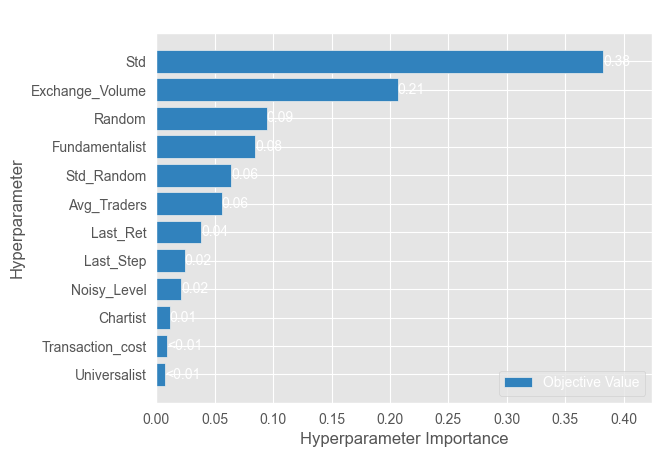

In [6]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

study = optuna.create_study(study_name="calibration_mse_v3 (mm-;volume+;diff diap)", direction="minimize", storage="sqlite:///calibration_mse_3.db",  load_if_exists=True)
plot_param_importances(study)
plt.show()